In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

**Summary**

* **Objective:** Build a machine learning model to predict fraudulent transactions.
* **Expected Outcome:** Reduce the percentage of fraudulent transactions by enabling early detection.
* **Workflow:**

  1. **Exploratory Data Analysis (EDA):** Assess data quality (e.g., missing values and outliers) and identify meaningful insights and patterns.
  2. **Build a Baseline Model:** Train an initial model and evaluate its performance using appropriate metrics.
  3. **Model Improvement:** Optimize the baseline model through feature engineering, hyperparameter tuning, or algorithm selection, if necessary.
  4. **Select the Decision Threshold (Cut-off):** Determine the optimal probability threshold based on business objectives and the trade-off between fraud detection and false positives.


## 1.EDA
- Kiểm tra chất lượng dữ liệu 
- Tìm hiểu 

In [2]:
df = pd.read_csv('Base.csv')

- Có bao nhiêu dữ liệu numerical và categorical

In [3]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

In [4]:
print("Number of numerical columns:", len(num_cols))
print("Number of categorical columns:", len(cat_cols))

Number of numerical columns: 27
Number of categorical columns: 5


In [5]:
print("Có missing value không: ", df.isnull().values.any())

Có missing value không:  False


### 1.1 Phân tích dữ liệu dạng số

- Kiểm tra phân phối dữ liệu để xem có lỗi dữ liệu nào không

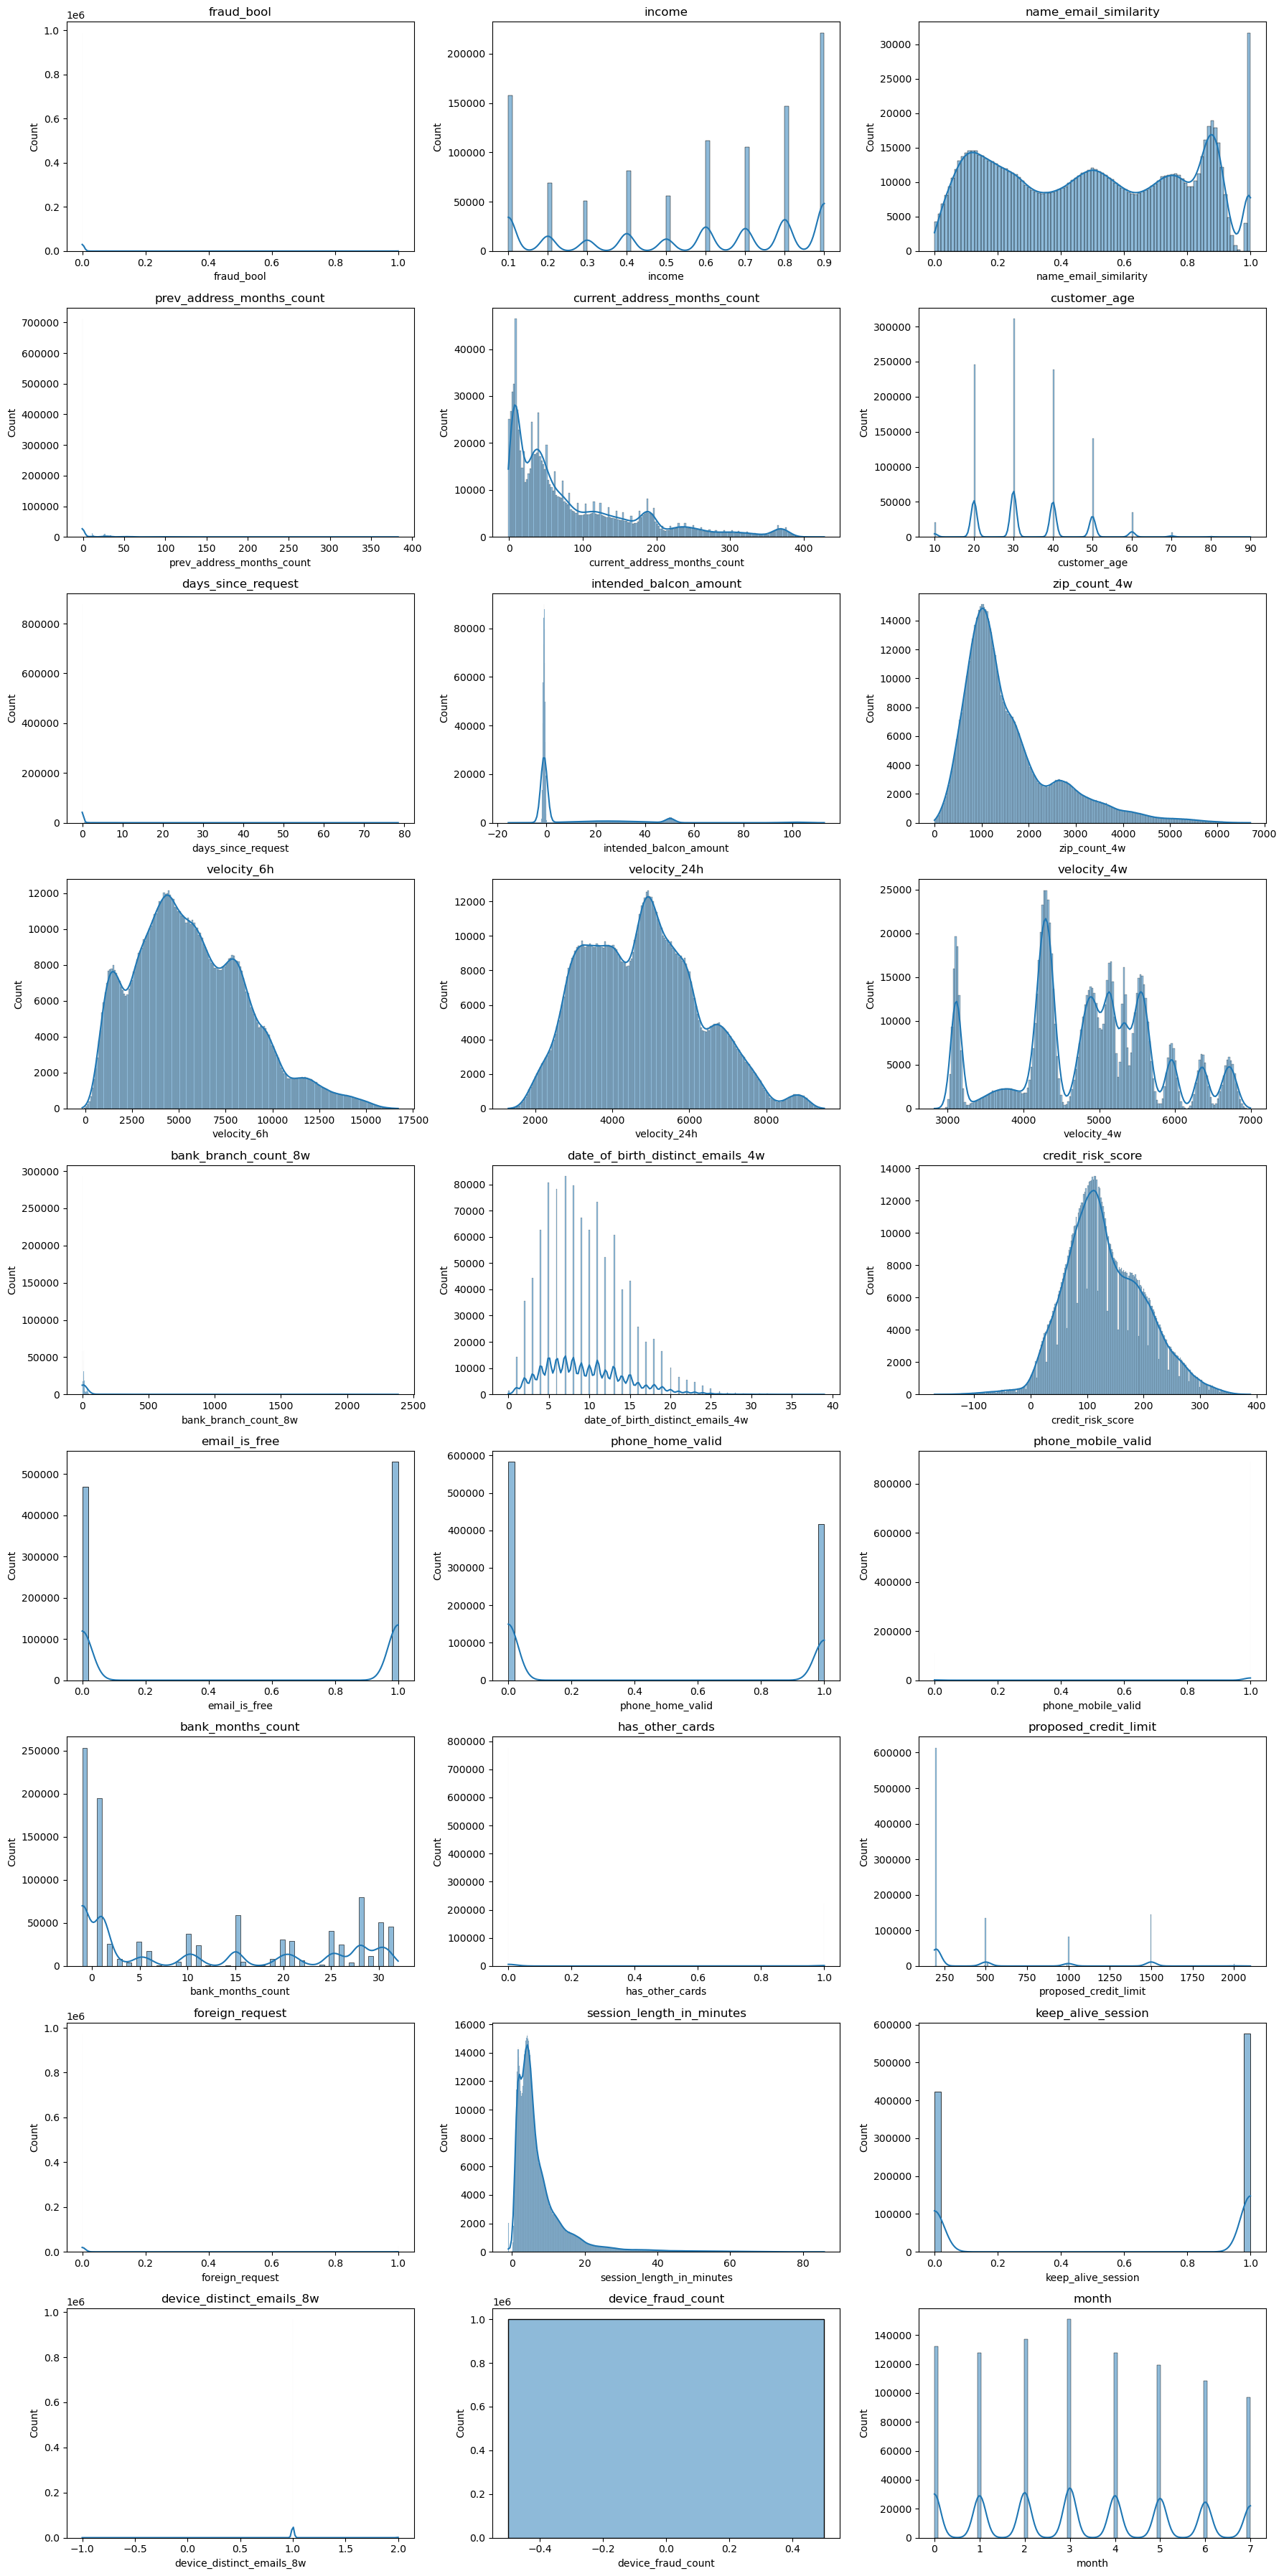

In [6]:
numeric_cols = df.select_dtypes(include=['number']).columns

n_cols = 3  # số plot mỗi hàng
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(6 * n_cols, 4 * n_rows)
)

# flatten để dễ truy cập
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(
        df[col].dropna(),
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(col)

# Ẩn các subplot thừa
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

- Demographic data: Độ tuổi khách hàng chủ yếu nằm ở độ tuổi khoảng cuối 20 đến đầu 40. Đặc điểm của nhóm khách hàng trên là đã hầu hết đã hoặc đang bước vào độ tuổi lập gia đình => nhu cầu tín dụng của tệp khách hàng trên có thể là mua nhà, xe hoặc các khoản tiền chi tiều thông dụng nếu khách hàng ở độ tuổi đầu 20.
-  Hầu hết data đều nằm trong range dữ liệu hơp lý ngoại trừ một số data ví dụ như device distinct emails 8w có một số dữ liệu -1 trong khi range data quy định là 0-3

In [7]:
df[(df['device_distinct_emails_8w'] < 0) | (df['device_distinct_emails_8w'] > 3)]['device_distinct_emails_8w'].value_counts()

device_distinct_emails_8w
-1    359
Name: count, dtype: int64

=> ý nghĩa của -1 trong bộ dataset: những giá trị -1 được quy định là missing value \
=> data có chứa nhiều null value

In [8]:
# Tính phần trăm missing value
ms_df = df.drop(columns=['credit_risk_score', 'intended_balcon_amount'], axis=1)
((ms_df == -1).sum() / len(ms_df) * 100).sort_values(ascending=False).head(10) 

prev_address_months_count       71.2920
bank_months_count               25.3635
current_address_months_count     0.4254
session_length_in_minutes        0.2015
device_distinct_emails_8w        0.0359
fraud_bool                       0.0000
housing_status                   0.0000
device_fraud_count               0.0000
keep_alive_session               0.0000
device_os                        0.0000
dtype: float64

=> có năm cột có missing value: device_distinct_emails_8w, device_distinct_emails_4w, device_distinct_emails_2w, device_distinct_emails_1w, device_distinct_emails_3d

In [9]:
df['intended_balcon_amount'].min()

-15.530554840076814

### 1.2 Phân tích dữ liệu dạng categorical

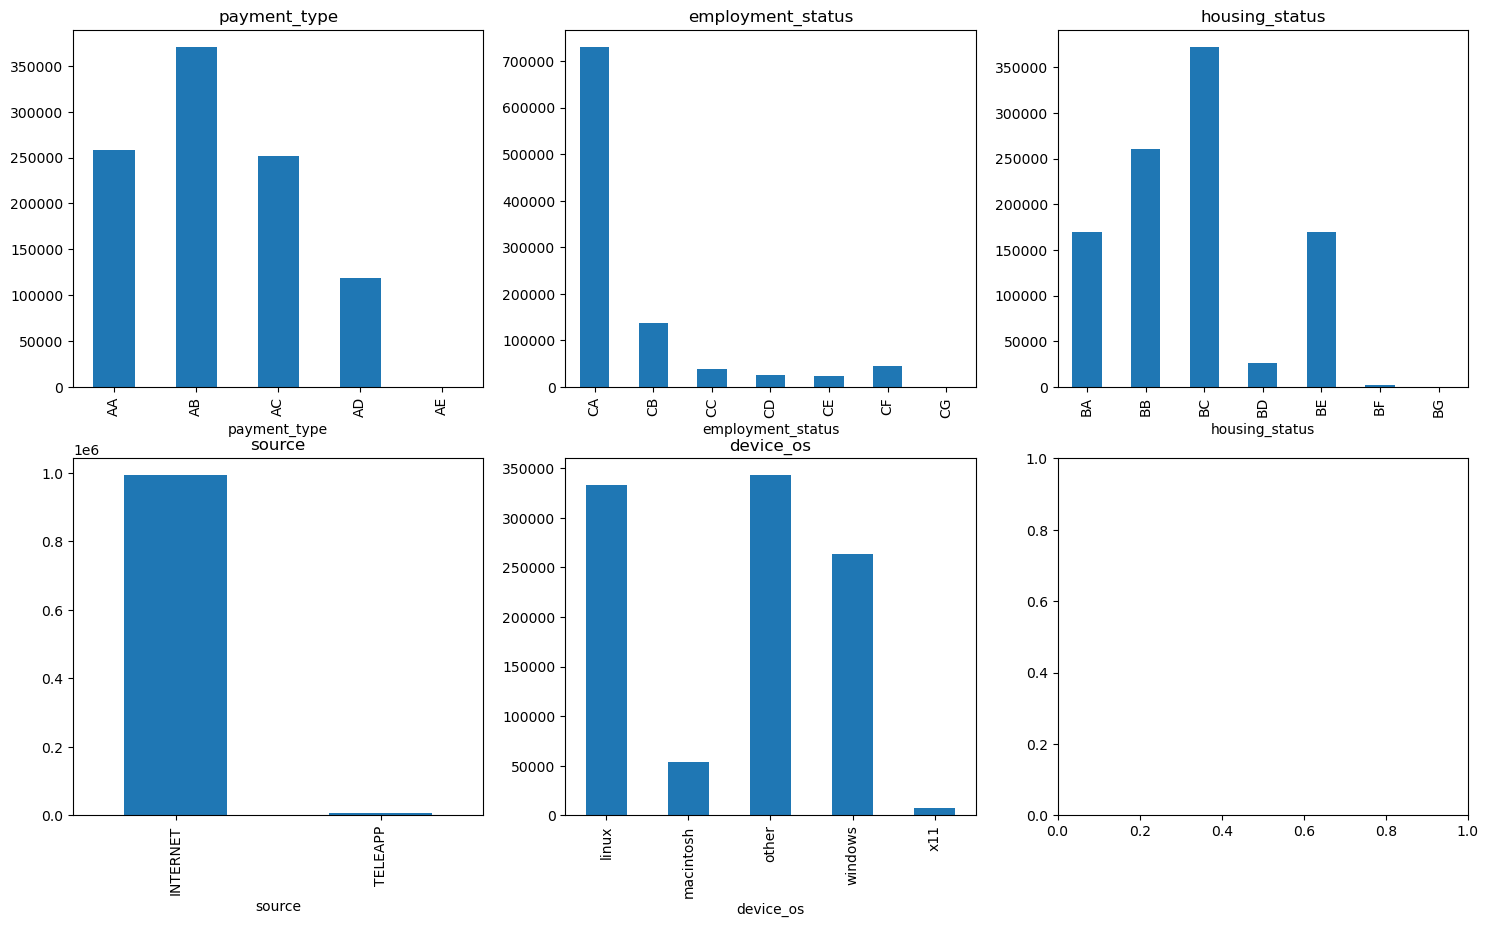

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(6 * 3, 5.1 * 2))

for i in range(len(cat_cols)):
    df[cat_cols[i]].value_counts().sort_index().plot(kind='bar', ax=axes[i // 3, i % 3], title=cat_cols[i])
# df['payment_type'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 0], title='Payment Type')

## 1.3 Phân tích phân phối target

<Axes: title={'center': 'Fraudulent vs Non-Fraudulent Transactions'}, xlabel='fraud_bool'>

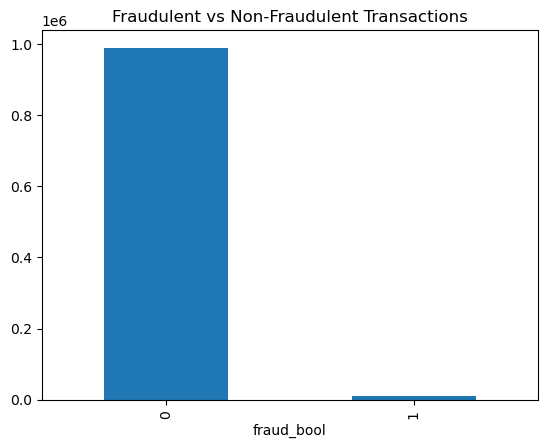

In [12]:
df['fraud_bool'].value_counts().plot(kind='bar', title='Fraudulent vs Non-Fraudulent Transactions')

=> dữ liệu bị imbalanced nặng những chỉ số như precision hay accuracy có thể không phản ánh đúng khả năng của model \
Suggestion: sử dụng SMOTE để sample data kết hợp với weight penalty

## 2. Build baseline model

Categorical: 5
Numerical: 26

LogisticRegression


c:\Users\NGOTHIANHDUONG\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Gini   : 0.7082
F1     : 0.0742
Recall : 0.7747


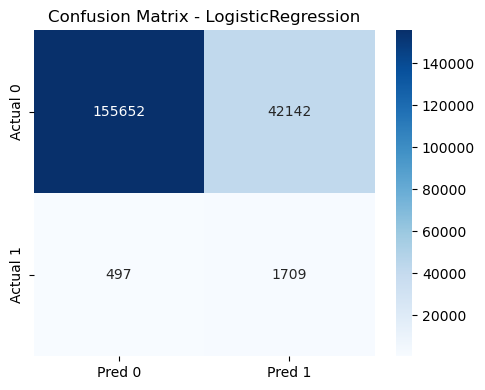


XGBoost
Gini   : 0.7869
F1     : 0.1057
Recall : 0.7502


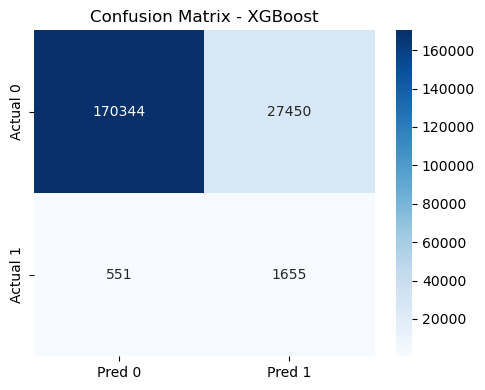


LightGBM
[LightGBM] [Info] Number of positive: 8823, number of negative: 791177
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.053462 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3213
[LightGBM] [Info] Number of data points in the train set: 800000, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496160
[LightGBM] [Info] Start training from score -4.496160
Gini   : 0.7839
F1     : 0.0967
Recall : 0.7801


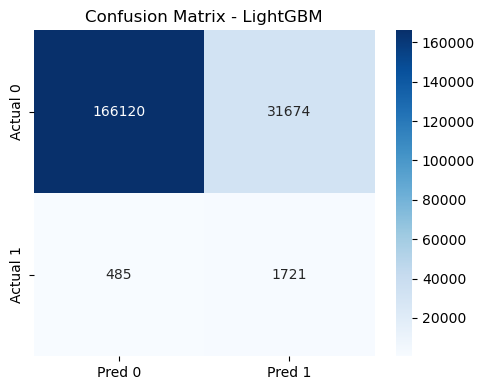


CatBoost
Gini   : 0.7948
F1     : 0.0952
Recall : 0.8055


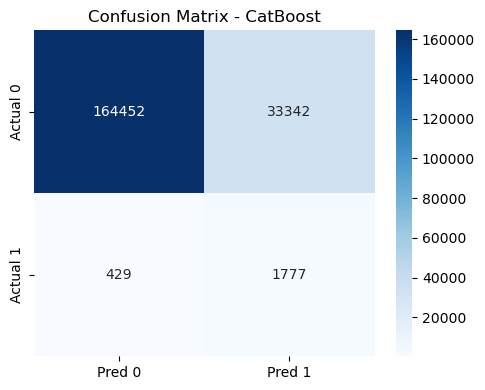


RESULTS
                Model      Gini        F1    Recall
3            CatBoost  0.794772  0.095218  0.805530
1             XGBoost  0.786878  0.105714  0.750227
2            LightGBM  0.783909  0.096683  0.780145
0  LogisticRegression  0.708204  0.074212  0.774705


In [13]:
# pip install pandas scikit-learn xgboost lightgbm catboost seaborn matplotlib

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    recall_score,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

# ====================================================
# LOAD DATA
# ====================================================
df = pd.read_csv("Base.csv")

TARGET = "fraud_bool"

X = df.drop(columns=[TARGET])
y = df[TARGET]

# ====================================================
# SPLIT
# ====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# ====================================================
# COLUMN TYPES
# ====================================================
cat_cols = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

num_cols = X.select_dtypes(
    exclude=["object", "category"]
).columns.tolist()

print("Categorical:", len(cat_cols))
print("Numerical:", len(num_cols))

# ====================================================
# IMBALANCE
# ====================================================
scale_pos_weight = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
)

# ====================================================
# PREPROCESS FOR LR + XGB
# ====================================================
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

X_train_ohe = preprocessor.fit_transform(X_train)
X_test_ohe = preprocessor.transform(X_test)

# ====================================================
# PREPROCESS FOR LIGHTGBM + CATBOOST
# ====================================================

X_train_native = X_train.copy()
X_test_native = X_test.copy()

# numerical missing
for col in num_cols:
    median = X_train_native[col].median()

    X_train_native[col] = X_train_native[col].fillna(median)
    X_test_native[col] = X_test_native[col].fillna(median)

# categorical missing
for col in cat_cols:

    X_train_native[col] = (
        X_train_native[col]
        .fillna("MISSING")
        .astype("category")
    )

    X_test_native[col] = (
        X_test_native[col]
        .fillna("MISSING")
        .astype("category")
    )

# ====================================================
# MODELS
# ====================================================
models = {

    "LogisticRegression": (
        LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=42
        ),
        X_train_ohe,
        X_test_ohe
    ),

    "XGBoost": (
        XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            random_state=42
        ),
        X_train_ohe,
        X_test_ohe
    ),

    "LightGBM": (
        LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            scale_pos_weight=scale_pos_weight,
            random_state=42
        ),
        X_train_native,
        X_test_native
    ),

    "CatBoost": (
        CatBoostClassifier(
            iterations=300,
            learning_rate=0.05,
            auto_class_weights="Balanced",
            verbose=0,
            random_state=42
        ),
        X_train_native,
        X_test_native
    )
}

# ====================================================
# TRAIN + EVALUATE
# ====================================================
results = []

for model_name, (model, Xtr, Xte) in models.items():

    print(f"\n{'='*60}")
    print(model_name)
    print(f"{'='*60}")

    if model_name == "CatBoost":

        model.fit(
            Xtr,
            y_train,
            cat_features=cat_cols
        )

    else:

        model.fit(Xtr, y_train)

    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]

    auc = roc_auc_score(y_test, y_prob)
    gini = 2 * auc - 1

    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    cm = confusion_matrix(y_test, y_pred)

    print(f"Gini   : {gini:.4f}")
    print(f"F1     : {f1:.4f}")
    print(f"Recall : {recall:.4f}")

    # ======================================
    # HEATMAP
    # ======================================
    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["Actual 0", "Actual 1"]
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()

    results.append({
        "Model": model_name,
        "Gini": gini,
        "F1": f1,
        "Recall": recall
    })

# ====================================================
# SUMMARY
# ====================================================
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Gini",
    ascending=False
)

print("\nRESULTS")
print(results_df)

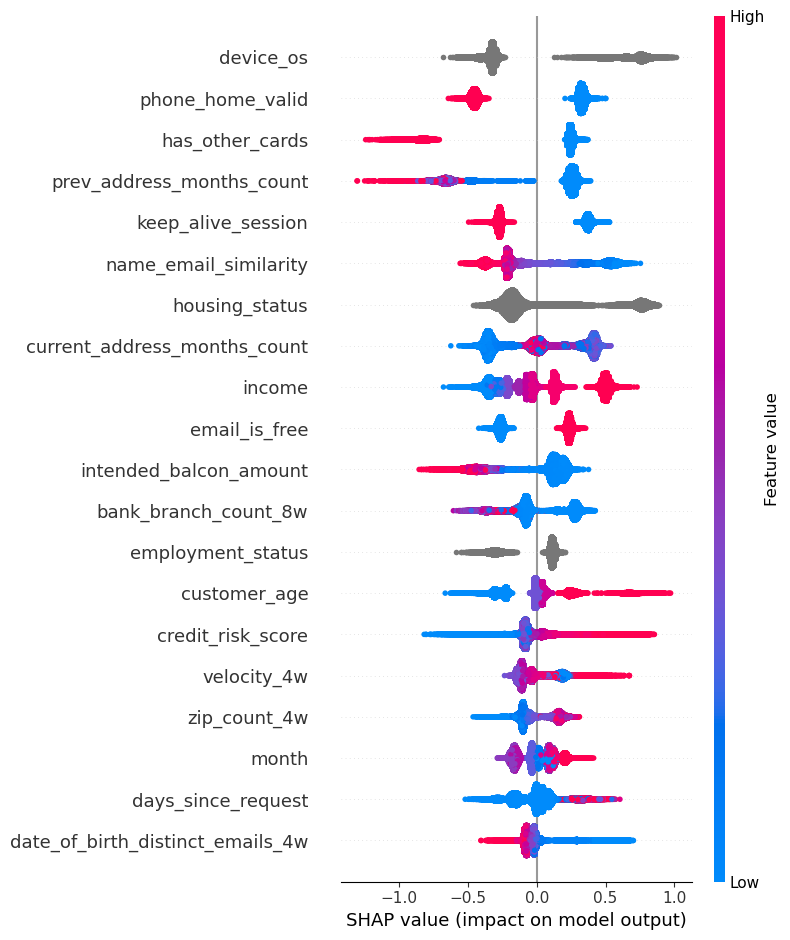

In [14]:
import shap
# explainer
explainer = shap.TreeExplainer(models['CatBoost'][0])

# shap values
shap_values = explainer.shap_values(X_test_native)

# summary plot
shap.summary_plot(
    shap_values,
    X_test_native,
    
)

- Phân tích các important features

In [15]:

# Create a DataFrame containing 4 copies of the first row
device_os_ana = pd.concat([X_train_native.iloc[:1]] * 5, ignore_index=True)
device_os_ana.iloc[0, device_os_ana.columns.get_loc('device_os')] = 'other'
device_os_ana.iloc[1, device_os_ana.columns.get_loc('device_os')] = 'linux'
device_os_ana.iloc[2, device_os_ana.columns.get_loc('device_os')] = 'windows'
device_os_ana.iloc[3, device_os_ana.columns.get_loc('device_os')] = 'macintosh'
device_os_ana.iloc[4, device_os_ana.columns.get_loc('device_os')] = 'x11'

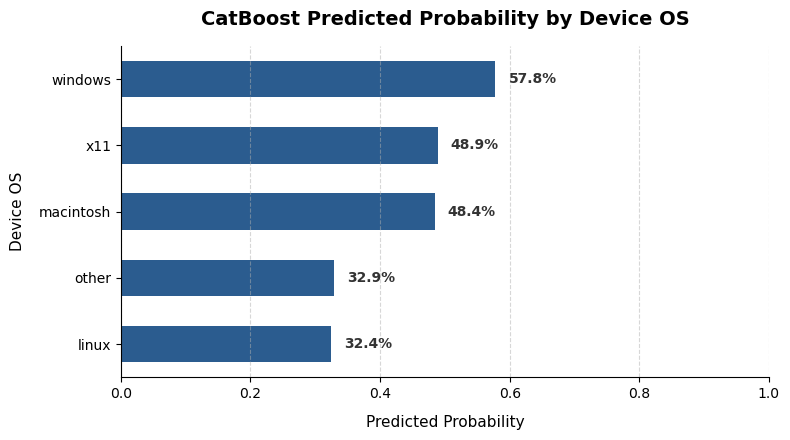

In [16]:
os_labels = device_os_ana['device_os']
probs = models['CatBoost'][0].predict_proba(device_os_ana)[:, 1]

# 2. Combine into a temporary DataFrame to sort the bars beautifully
plot_df = pd.DataFrame({
    'Device OS': os_labels,
    'Probability': probs
}).sort_values(by='Probability', ascending=True)

# 3. Initialize a clean, modern subplot
fig, ax = plt.subplots(figsize=(8, 4.5))

# Plot horizontal bars
bars = ax.barh(plot_df['Device OS'], plot_df['Probability'], color='#2b5c8f', height=0.55)

# 4. Enhance formatting and context
ax.set_title('CatBoost Predicted Probability by Device OS', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Probability', fontsize=11, labelpad=10)
ax.set_ylabel('Device OS', fontsize=11, labelpad=10)

# Set the X-axis limit to 100% since probabilities are bounded between 0 and 1
ax.set_xlim(0, 1.0)

# Add light vertical gridlines for readability
ax.grid(axis='x', linestyle='--', alpha=0.5)

# 5. Add exact percentage labels to the end of each bar
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.02, bar.get_y() + bar.get_height()/2, f'{width:.1%}', 
            va='center', ha='left', fontsize=10, fontweight='semibold', color='#333333')

# Remove the top and right borders (spines) for a clean, minimalist aesthetic
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

# Clean up layout margins and save/show
plt.tight_layout()
plt.savefig('device_os_probabilities.png', dpi=300)

- Dựa trên model catboost, một người thực hiện giao dịch trên device os là windows có tỉ lệ fraud cao nhất điều này đặt ra giả thuyết các tội phạm không phải là tội phạm công nghệ cao, mà thường là người bình thường họ vô tình hoặc cố ý trộm các thẻ tín dụng để thực hiện hành vi fraud thay vì là một người có kĩ năng cao về công nghệ.

In [17]:
phone_home_ana =   pd.concat([X_train_native.iloc[:1]] * 2, ignore_index=True)
phone_home_ana.iloc[1, phone_home_ana.columns.get_loc('phone_home_valid')] = 1

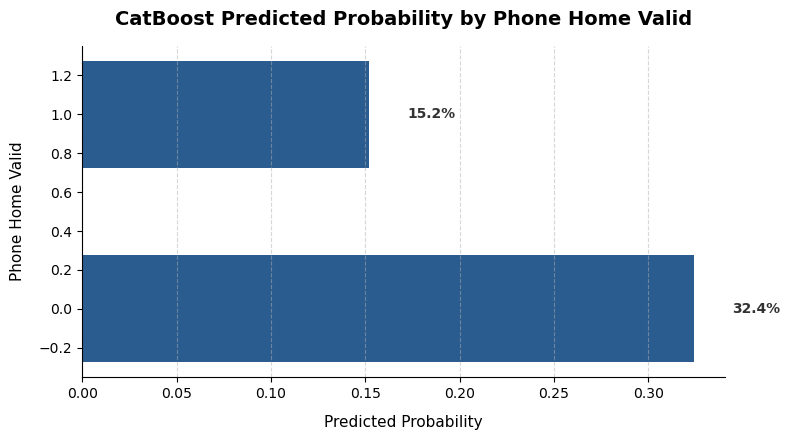

In [18]:
os_labels = phone_home_ana['phone_home_valid']
probs = models['CatBoost'][0].predict_proba(phone_home_ana)[:, 1]

# 2. Combine into a temporary DataFrame to sort the bars beautifully
plot_df = pd.DataFrame({
    'Phone Home Valid': os_labels,
    'Probability': probs
}).sort_values(by='Probability', ascending=True)

# 3. Initialize a clean, modern subplot
fig, ax = plt.subplots(figsize=(8, 4.5))

# Plot horizontal bars
bars = ax.barh(plot_df['Phone Home Valid'], plot_df['Probability'], color='#2b5c8f', height=0.55)

# 4. Enhance formatting and context
ax.set_title('CatBoost Predicted Probability by Phone Home Valid', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Probability', fontsize=11, labelpad=10)
ax.set_ylabel('Phone Home Valid', fontsize=11, labelpad=10)

# Set the X-axis limit to 100% since probabilities are bounded between 0 and 1
# ax.set_xlim(0, 1.0)

# Add light vertical gridlines for readability
ax.grid(axis='x', linestyle='--', alpha=0.5)

# 5. Add exact percentage labels to the end of each bar
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.02, bar.get_y() + bar.get_height()/2, f'{width:.1%}', 
            va='center', ha='left', fontsize=10, fontweight='semibold', color='#333333')

# Remove the top and right borders (spines) for a clean, minimalist aesthetic
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

# Clean up layout margins and save/show
plt.tight_layout()
plt.savefig('phone_home_probabilities.png', dpi=300)

- Các giao dịch có số điện thoại nhà không hợp lệ có xác suất gian lận cao hơn so với các giao dịch có số điện thoại hợp lệ.

In [19]:
cb_y_prob = models['CatBoost'][0].predict_proba(X_test_native)[:, 1]
cut_offs = np.linspace(0, 1, 1000)
fraud_rates = pd.DataFrame({
    "cut_off": cut_offs,
    "fraud transactions": [((y_test.sum() - ((cb_y_prob >= cut) & y_test).sum()))for cut in cut_offs],
    "fraud %": [((y_test.sum() - ((cb_y_prob >= cut) & y_test).sum())/ len(y_test))for cut in cut_offs],
     "good transactions %": [(((cb_y_prob < cut) & ~y_test).sum() / (y_test == 0).sum()) for cut in cut_offs]})

<Axes: title={'center': 'Fraud Rate vs Cut-off'}, xlabel='cut_off'>

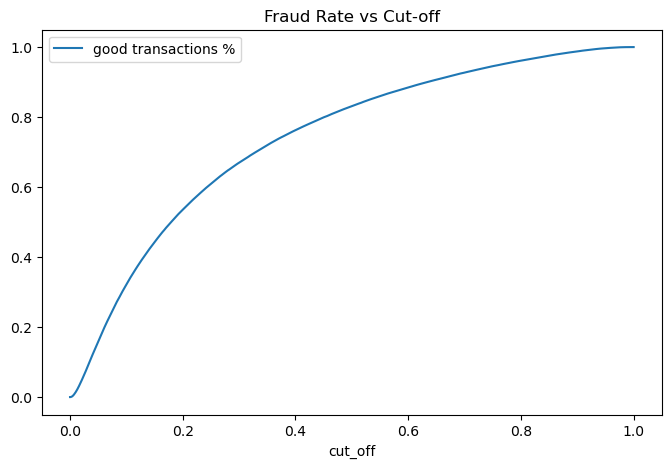

In [20]:
fraud_rates.plot(
    x="cut_off",
    y="good transactions %",
    title="Fraud Rate vs Cut-off",
    figsize=(8, 5)
)

<Axes: title={'center': 'Fraud Rate vs Cut-off'}, xlabel='cut_off'>

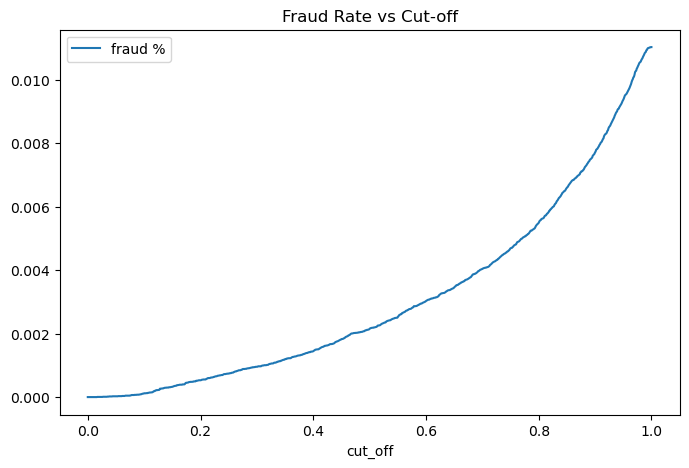

In [21]:
fraud_rates.plot(
    x="cut_off",
    y="fraud %",
    title="Fraud Rate vs Cut-off",
    figsize=(8, 5)
)

In [22]:
fraud_cutoff =fraud_rates[fraud_rates['good transactions %'] >= 0.7]['fraud %'].min()
best_cutoff = fraud_rates[fraud_rates['fraud %'] == fraud_cutoff]['cut_off'].values[0]

In [32]:
display(fraud_rates[fraud_rates['fraud %'] == fraud_cutoff])
display(fraud_rates.tail(1))

,cut_off,fraud transactions,fraud %,good transactions %
330,0.33033,216,0.00108,0.700941


,cut_off,fraud transactions,fraud %,good transactions %
999,1.0,2206,0.01103,1.0


In [40]:
print("Best cutoff:", best_cutoff.tolist())

Best cutoff: 0.3303303303303303



- **Ý nghĩa của việc lựa chọn cut-off:** Mức cut-off được thiết lập nhằm đảm bảo **ít nhất 70% giao dịch hợp lệ được phê duyệt tự động**, trong khi **30% giao dịch còn lại được đưa vào nhóm nghi ngờ** để thực hiện các bước kiểm tra bổ sung. Các giao dịch trong nhóm này sẽ được xác minh nhằm xác định liệu có phải là giao dịch gian lận hay không trước khi đưa ra quyết định cuối cùng.
- **Hiệu quả của cut-off:** Với mức cut-off đã chọn, tỷ lệ gian lận giảm từ 0,01103% xuống còn 0,00108%, tương đương **mức giảm khoảng 90%.**
 - Tuy nhiên, đánh đổi là khoảng **30% giao dịch hợp lệ sẽ không được phê duyệt ngay lập tức và cần trải qua bước xác minh bổ sung**. Để giảm thiểu tác động đến trải nghiệm khách hàng, các giao dịch nghi ngờ có thể được xác thực thông qua SMS, cuộc gọi hoặc các phương thức xác thực đa yếu tố (MFA) nhằm xác nhận giao dịch được thực hiện bởi chính chủ. Cách tiếp cận này giúp duy trì hiệu quả phát hiện gian lận đồng thời hạn chế việc từ chối hoặc trì hoãn các giao dịch hợp lệ.

## 3. Improve baseline

In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE


# SMOTE only the training data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_ohe, y_train)

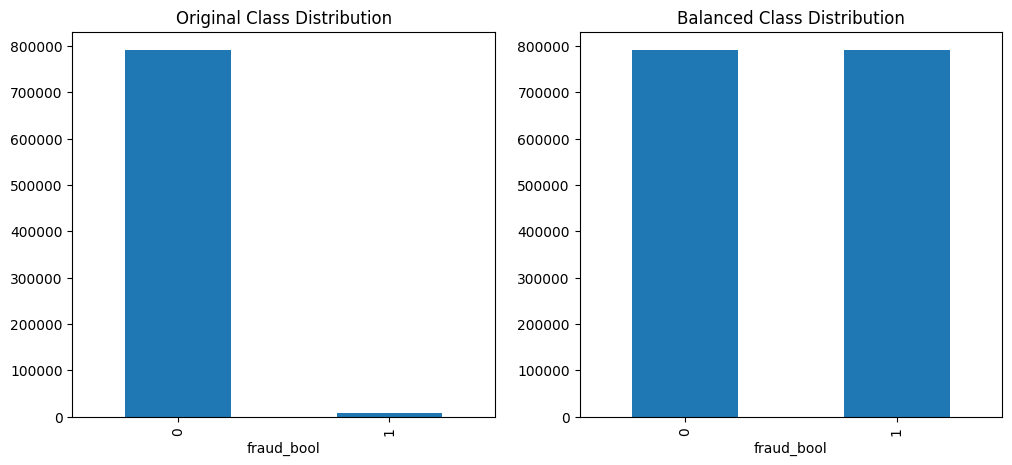

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
y_train.value_counts().plot(kind='bar', title='Original Class Distribution', ax=axes[0])
y_train_balanced.value_counts().plot(kind='bar', title='Balanced Class Distribution', ax=axes[1])
plt.show()


LogisticRegression


/home/duong/miniconda3/envs/vscode-test/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Gini   : 0.7221
F1     : 0.0801
Recall : 0.7733


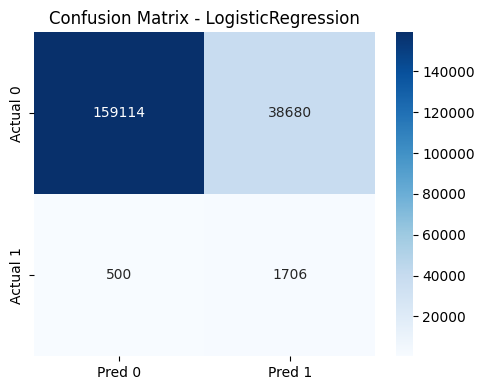


XGBoost
Gini   : 0.7806
F1     : 0.0841
Recall : 0.8182


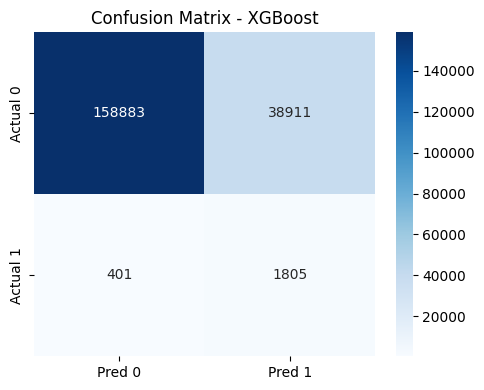


LightGBM
[LightGBM] [Info] Number of positive: 791177, number of negative: 791177
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.182267 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12084
[LightGBM] [Info] Number of data points in the train set: 1582354, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/home/duong/miniconda3/envs/vscode-test/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/duong/miniconda3/envs/vscode-test/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Gini   : 0.7884
F1     : 0.0921
Recall : 0.7960


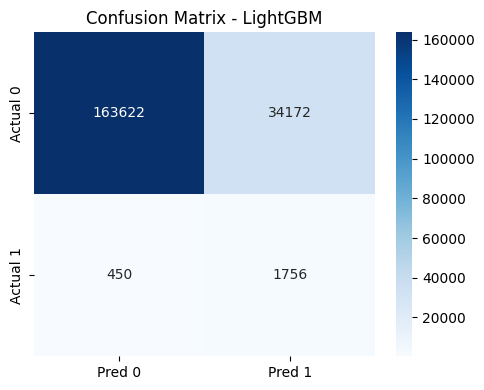


CatBoost
Gini   : 0.7861
F1     : 0.0659
Recall : 0.0349


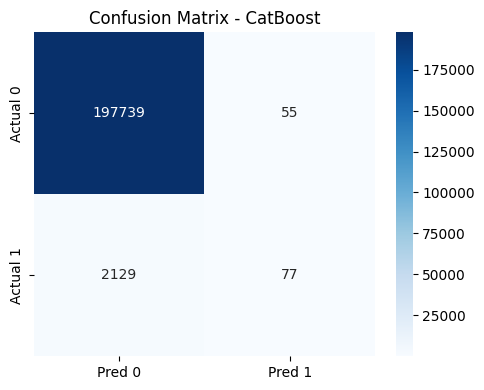


RESULTS
                Model      Gini        F1    Recall
2            LightGBM  0.788420  0.092096  0.796011
3            CatBoost  0.786055  0.065868  0.034905
1             XGBoost  0.780552  0.084106  0.818223
0  LogisticRegression  0.722100  0.080109  0.773345


In [ ]:
models = {

    "LogisticRegression": (
        LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=42
        ),
        X_train_balanced,
        X_test_ohe
    ),

    "XGBoost": (
        XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            random_state=42
        ),
        X_train_balanced,
        X_test_ohe
    ),

    "LightGBM": (
        LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            scale_pos_weight=scale_pos_weight,
            random_state=42
        ),
        X_train_balanced,
        X_test_ohe
    ),

    "CatBoost": (
        CatBoostClassifier(
            iterations=300,
            learning_rate=0.05,
            auto_class_weights="Balanced",
            verbose=0,
            random_state=42
        ),
        X_train_balanced,
        X_test_ohe
    )
}

# ====================================================
# TRAIN + EVALUATE
# ====================================================
results = []

for model_name, (model, Xtr, Xte) in models.items():

    print(f"\n{'='*60}")
    print(model_name)
    print(f"{'='*60}")

    if model_name == "CatBoost":

        model.fit(
            Xtr,
            y_train_balanced
        )

    else:

        model.fit(Xtr, y_train_balanced)

    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]

    auc = roc_auc_score(y_test, y_prob)
    gini = 2 * auc - 1

    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    cm = confusion_matrix(y_test, y_pred)

    print(f"Gini   : {gini:.4f}")
    print(f"F1     : {f1:.4f}")
    print(f"Recall : {recall:.4f}")

    # ======================================
    # HEATMAP
    # ======================================
    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["Actual 0", "Actual 1"]
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()

    results.append({
        "Model": model_name,
        "Gini": gini,
        "F1": f1,
        "Recall": recall
    })

# ====================================================
# SUMMARY
# ====================================================
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Gini",
    ascending=False
)

print("\nRESULTS")
print(results_df)

In [ ]:
fraud_rates.plot(
    x="cut_off",
    y="good transactions %",
    title="Fraud Rate vs Cut-off",
    figsize=(8, 5)
)

In [ ]:
fraud_rates.plot(
    x="cut_off",
    y="fraud %",
    title="Fraud Rate vs Cut-off",
    figsize=(8, 5)
)